# Dự đoán Doanh số Bán hàng theo Ngày (Daily Sales Volume Forecasting)

Notebook này minh họa quá trình dự báo lượng đơn hàng theo chuỗi thời gian, đồng thời so sánh 2 thuật toán tự code từ đầu: Linear Regression và Decision Tree.

In [1]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Thiết lập đường dẫn động
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
else:
    project_root = current_dir
src_path = os.path.join(project_root, 'src')
sys.path.insert(0, project_root)

from src.models.preprocessing import time_series_split, StandardScaler
from src.models.linear_regression import LinearRegression
from src.models.decision_tree import DecisionTreeRegressor
from src.models.metrics import mean_absolute_error, root_mean_squared_error
from src.features.build_features import extract_date_features

print("Modules loaded successfully.")

Modules loaded successfully.


### 1. Chuẩn bị Dữ liệu (Data Aggregation)

In [2]:
data_path = os.path.join(project_root, 'data', 'raw', 'ecommerce_dataset_updated.csv')
df_raw = pd.read_csv(data_path)
df_raw['Purchase_Date'] = pd.to_datetime(df_raw['Purchase_Date'], format='%d-%m-%Y', dayfirst=True)
df_daily = df_raw.groupby('Purchase_Date').size().reset_index(name='Daily_Volume')
df_daily = df_daily.sort_values(by='Purchase_Date').reset_index(drop=True)
df_daily.head()

,Purchase_Date,Daily_Volume
0,2024-01-01,7
1,2024-01-02,17
2,2024-01-03,9
3,2024-01-04,10
4,2024-01-05,12


### 2. Feature Engineering

In [3]:
df_daily['Purchase_Date_Str'] = df_daily['Purchase_Date'].dt.strftime('%d-%m-%Y')
df_features = extract_date_features(df_daily, date_column='Purchase_Date_Str')
df_features = df_features.drop(columns=['Purchase_Date', 'Purchase_Date_Str'])
df_features.head()

,Daily_Volume,Purchase_Year,Purchase_Month,Purchase_Day,Purchase_DayOfWeek,Purchase_IsWeekend
0,7,2024,1,1,0,0
1,17,2024,1,2,1,0
2,9,2024,1,3,2,0
3,10,2024,1,4,3,0
4,12,2024,1,5,4,0


### 3. Phân chia Dữ liệu và Chuẩn hóa

In [4]:
target_col = 'Daily_Volume'
X = df_features.drop(columns=[target_col])
y = df_features[target_col]

X_train, X_test, y_train, y_test = time_series_split(X, y, test_size=0.2)

scaler = StandardScaler()
numeric_cols = ['Purchase_Year', 'Purchase_Month', 'Purchase_Day', 'Purchase_DayOfWeek']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
scaler.fit(X_train[numeric_cols])
X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


### 4. Huấn luyện 2 mô hình (Model Selection)

In [5]:
# Mô hình 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Mô hình 2: Decision Tree Regressor (Max Depth = 4 chống overfitting)
dt_model = DecisionTreeRegressor(max_depth=4)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Huấn luyện thành công cả 2 mô hình!")

Huấn luyện thành công cả 2 mô hình!


### 5. Đánh giá và Trực quan hóa

--- Kết quả Linear Regression ---
MAE: 2.44
RMSE: 2.95

--- Kết quả Decision Tree ---
MAE: 2.89
RMSE: 3.48


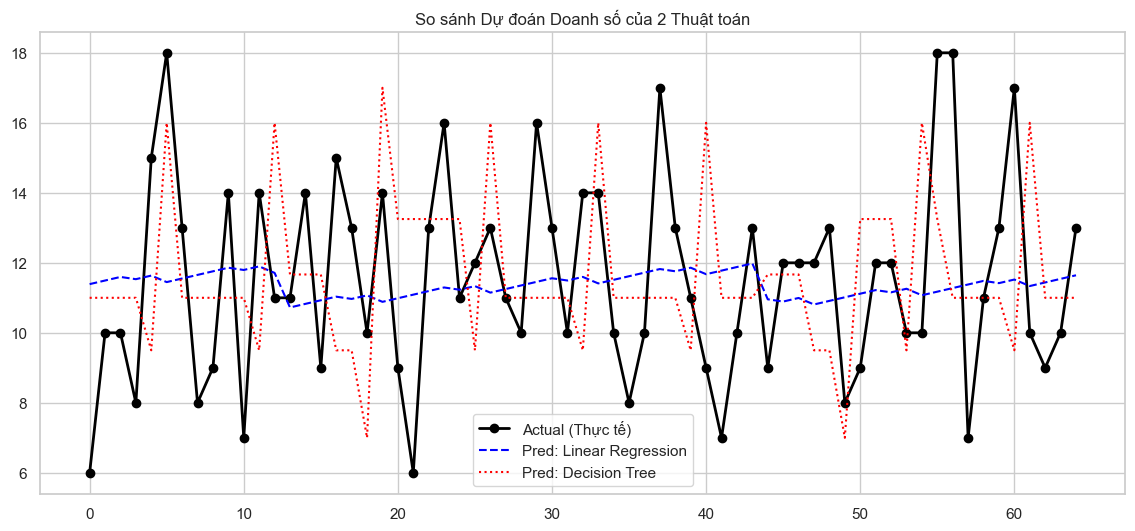

In [6]:
print("--- Kết quả Linear Regression ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_lr):.2f}\n")

print("--- Kết quả Decision Tree ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_dt):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_dt):.2f}")

plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(y_test)), y_test.values, label='Actual (Thực tế)', color='black', marker='o', linewidth=2)
plt.plot(np.arange(len(y_test)), y_pred_lr, label='Pred: Linear Regression', color='blue', linestyle='--')
plt.plot(np.arange(len(y_test)), y_pred_dt, label='Pred: Decision Tree', color='red', linestyle=':')
plt.title('So sánh Dự đoán Doanh số của 2 Thuật toán')
plt.legend()
plt.show()

### 6. Đóng gói mô hình tốt nhất (Deployment Prep)
Mặc dù Decision Tree có khả năng học phi tuyến tính tốt, chúng ta tạm lưu Decision Tree làm mô hình chính để đưa lên Web API.

In [7]:
models_dir = os.path.join(project_root, 'src.models')
os.makedirs(models_dir, exist_ok=True)

# Lưu mô hình Cây Quyết định và Scaler
dt_model.save(os.path.join(models_dir, 'decision_tree.pkl'))
scaler.save(os.path.join(models_dir, 'scaler.pkl'))

print("Mô hình và Scaler đã được lưu để phục vụ Web API!")

Mô hình và Scaler đã được lưu để phục vụ Web API!
